<a href="https://colab.research.google.com/github/minhasaleem/DATASCIENCE-LAB/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

In [3]:
data = load_iris()

In [4]:
data.data.shape

(150, 4)

In [5]:
print('classes to predict: ',data.target_names)
print('features: ',data.feature_names)

classes to predict:  ['setosa' 'versicolor' 'virginica']
features:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [6]:
x = data.data
y = data.target
display (x.shape,y.shape)

(150, 4)

(150,)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [8]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,random_state = 50,
test_size = 0.25)

In [9]:
classifier = DecisionTreeClassifier()
classifier.fit(xtrain,ytrain)
DecisionTreeClassifier()
y_pred = classifier.predict(xtest)

In [13]:
from sklearn.metrics import accuracy_score
print('Accuracy on train data using Gini:', accuracy_score(ytrain, classifier.predict(xtrain)))
print('Accuracy on test data using Gini:', accuracy_score(ytest, y_pred))

Accuracy on train data using Gini: 1.0
Accuracy on test data using Gini: 0.9473684210526315


In [14]:
classifier_entropy = DecisionTreeClassifier(criterion ='entropy')
classifier_entropy.fit(xtrain,ytrain)
y_pred_entropy = classifier_entropy.predict(xtest)
print('Accuracy on train data using entropy',
accuracy_score(ytrain,classifier.predict(xtrain)))
print('Accuracy on test data using entropy',
accuracy_score(ytest,y_pred_entropy))

Accuracy on train data using entropy 1.0
Accuracy on test data using entropy 0.9473684210526315


In [15]:
classifier_entropy1 = DecisionTreeClassifier(criterion = 'entropy',
min_samples_split=50)

In [16]:
classifier_entropy1.fit(xtrain,ytrain)
y_pred_entropy1 = classifier_entropy1.predict(xtest)
print('Accuracy on train data using entropy',
accuracy_score(y_true=ytrain, y_pred=
classifier_entropy1.predict(xtrain)))
print('Accuracy on test data using entropy', accuracy_score(y_true =
ytest, y_pred = y_pred_entropy1))

Accuracy on train data using entropy 0.9642857142857143
Accuracy on test data using entropy 0.9473684210526315


In [17]:
from sklearn.tree import export_graphviz     #for visualization
from six import StringIO

In [18]:
from IPython.display import Image

In [19]:
import pydotplus

In [20]:
dot_data = StringIO()

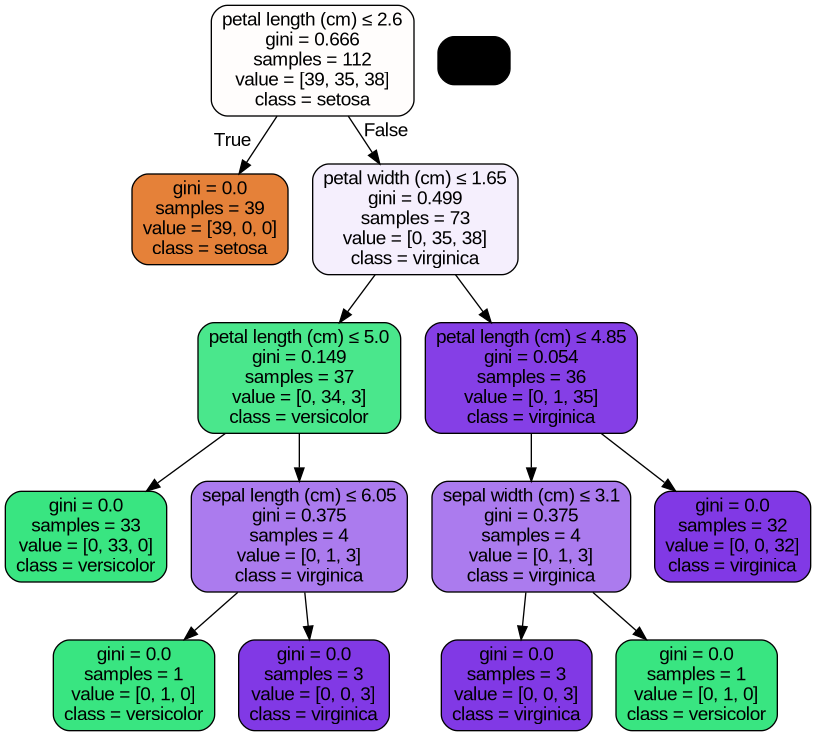

In [21]:
export_graphviz(classifier, out_file = dot_data, filled = True,
rounded = True, special_characters = True, feature_names
=data.feature_names, class_names = data.target_names)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())